# Filtro de Kalman Manual

Andrés Jaramillo - A01029079

Pedro Mauri Mtz - A01029143

# Imports de librerías

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import ldl
from scipy.special import factorial

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

In [2]:
# Configuración para prints:
np.set_printoptions(precision = 4, suppress = False, linewidth = 999999)

# Lectura y extracción de Data

In [3]:
df = pd.read_csv(ROOT + "/Datasets/User1_Pre2.csv")

data = np.array(df)

print(data.shape)
print(data)

(3072, 14)
[[ 1.5476  0.6907  0.5214 ...  2.1658  4.1376  2.0396]
 [13.3758  7.1104  8.5284 ...  1.952   7.1215  5.7523]
 [10.274   5.7998  5.8173 ...  1.0845  5.3174  4.4058]
 ...
 [ 2.481   3.916   3.8288 ... -1.6257 -6.1869 -1.6642]
 [ 1.6187  1.2356  2.5946 ... -1.4241 -7.2008 -1.835 ]
 [ 0.4386  0.1822  0.248  ...  0.1964 -0.1162  0.2026]]


## Matriz de Covarianza

In [4]:
P = np.cov(data, rowvar = False)

print(P.shape)
print(P)

(14, 14)
[[ 6.6882e+01  6.2510e+01  5.2156e+01  3.1571e+01  2.6613e+01  1.3648e-02 -6.2762e-03  3.8995e+00  3.2984e+00  1.3655e+02  4.3937e+01  2.9188e+01  6.4821e+01  3.9299e+01]
 [ 6.2510e+01  6.9694e+01  5.1988e+01  3.4083e+01  3.0020e+01  5.5388e-02 -1.6708e-03  3.4835e+00  2.9941e+00  1.4229e+02  4.5894e+01  2.8233e+01  6.5577e+01  3.7110e+01]
 [ 5.2156e+01  5.1988e+01  4.3591e+01  2.9329e+01  2.2328e+01  1.7712e-02 -7.4982e-02  3.0941e+00  2.6940e+00  1.1918e+02  3.8678e+01  2.4909e+01  5.3142e+01  3.1118e+01]
 [ 3.1571e+01  3.4083e+01  2.9329e+01  2.7843e+01  1.2797e+01  7.9410e-04 -8.5214e-03  2.7978e+00  1.9030e+00  7.0229e+01  2.0858e+01  1.4368e+01  3.1885e+01  1.8086e+01]
 [ 2.6613e+01  3.0020e+01  2.2328e+01  1.2797e+01  2.2649e+01  5.7676e-03 -1.1244e-02 -1.5567e+00 -7.9594e-01  7.6218e+01  2.4988e+01  1.1716e+01  3.1943e+01  1.5909e+01]
 [ 1.3648e-02  5.5388e-02  1.7712e-02  7.9410e-04  5.7676e-03  3.2204e-04 -3.7344e-04 -6.8131e-04  2.3398e-03  6.2653e-02  2.2524e-02  4

# Delta Time

In [5]:
# Frecuencia
dt = 1 / 128

# Ruido Balanco Random

In [6]:
w = np.abs(np.random.normal(0, 1e-3, len(data[0])))

# Genera una matriz base aleatoria con ruido pequeño
q_ini = np.random.normal(0, 1e-3, (len(data[0]), len(data[0])))
r_ini = np.random.normal(0, 1e-3, (len(data[0]), len(data[0])))

# Asegura simetría y positividad definida (multiplicando por su traspuesta)
Q = np.abs(q_ini @ q_ini.T)
R = np.abs(r_ini @ r_ini.T)

Z = np.abs(np.random.normal(0, 1e-3, len(data[0])))


# H

In [7]:
H = np.eye(14)

print(H.shape)
print(H)

(14, 14)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


# LDLT

In [8]:
L, D, LT = ldl(P)

Diagonal = np.zeros_like(D)

for i in range(len(D)):
    Diagonal[i, i] = np.sqrt(D[i, i])

S = L @ Diagonal

print(S.shape)
print(S)

(14, 14)
[[ 8.1782e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 7.6435e+00  3.3571e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 6.3775e+00  9.6533e-01  1.4094e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 3.8605e+00  1.3630e+00  2.4072e+00  2.2995e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 3.2541e+00  1.5331e+00  6.7045e-02 -8.7672e-01  2.9893e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 1.6689e-03  1.2699e-02 -3.6822e-03 -6.1290e-03 -8.1151e-03  6.4040e-03  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0

# Taylor Series

In [9]:
def Taylor_series(dt):

    F = np.eye(14)

    for k in range(1, 15):
        values = (dt ** k) / factorial(k)
        F += np.diag(np.full(14 - k, values), k)

    return F

F = Taylor_series(dt)

print(F.shape)
print(F)

(14, 14)
[[1.0000e+00 7.8125e-03 3.0518e-05 7.9473e-08 1.5522e-10 2.4253e-13 3.1580e-16 3.5245e-19 3.4419e-22 2.9878e-25 2.3342e-28 1.6578e-31 1.0793e-34 6.4862e-38]
 [0.0000e+00 1.0000e+00 7.8125e-03 3.0518e-05 7.9473e-08 1.5522e-10 2.4253e-13 3.1580e-16 3.5245e-19 3.4419e-22 2.9878e-25 2.3342e-28 1.6578e-31 1.0793e-34]
 [0.0000e+00 0.0000e+00 1.0000e+00 7.8125e-03 3.0518e-05 7.9473e-08 1.5522e-10 2.4253e-13 3.1580e-16 3.5245e-19 3.4419e-22 2.9878e-25 2.3342e-28 1.6578e-31]
 [0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 7.8125e-03 3.0518e-05 7.9473e-08 1.5522e-10 2.4253e-13 3.1580e-16 3.5245e-19 3.4419e-22 2.9878e-25 2.3342e-28]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 7.8125e-03 3.0518e-05 7.9473e-08 1.5522e-10 2.4253e-13 3.1580e-16 3.5245e-19 3.4419e-22 2.9878e-25]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 7.8125e-03 3.0518e-05 7.9473e-08 1.5522e-10 2.4253e-13 3.1580e-16 3.5245e-19 3.4419e-22]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0

# Givens Rotation

In [10]:
def Givens_rotation(F, Qt, St):

  m = St.shape[0]

  U = np.vstack((F @ St, Qt)).astype(float, copy = True)

  rows, cols = U.shape

  for col in range(cols):

    for row in range(rows -1, col, -1):

      upper_val = U[row - 1, col]
      lower_val = U[row, col]

      I = np.eye(m)

      if lower_val == 0:
        cosine = 1
        sine = 0
      else:
        if abs(lower_val) > abs(upper_val):
          r = upper_val / lower_val
          sine = 1 / np.sqrt(1 + r ** 2)
          cosine = sine * r
        else:
          r = lower_val / upper_val
          cosine = 1 / np.sqrt(1 + r ** 2)
          sine = cosine * r

      upper_row = U[row - 1, :].copy()
      lower_row = U[row, :].copy()
      U[row - 1, :] = cosine * upper_row - sine * lower_row
      U[row, :] = sine * upper_row + cosine * lower_row

      S = U[:cols, :]

  return S

# Potter's Algorithm

In [11]:
def Potter(x, S, y, H, R, eps = 1e-9):

  x = np.asarray(x, float).reshape(-1, 1) # (m,1)
  S = np.asarray(S, float)
  y = np.asarray(y, float).reshape(-1) # (n,)
  H = np.asarray(H, float)
  R = np.asarray(R, float)

  m = S.shape[0]
  I = np.eye(m)

  for i in range(y.size):

    h = H[i, :].reshape(1, m)
    r = R[i, i]

    phi = S.T @ h.T
    den = (phi.T @ phi).item() + r

    alpha = 1.0 / den
    ar = max(alpha * r, 0.0)
    gamma = alpha / (1.0 + np.sqrt(ar))

    # K con S "anterior"
    K = (S @ phi) / den

    # Innovación escalar
    y_pred = float((h @ x).item())
    innov  = y[i] - y_pred

    # Actualizar estado
    x = x + K * innov

    # Actualizar S con identidad de tamaño m
    S = S @ (I - (alpha * gamma) * (phi @ phi.T))

  return x, S

# Kalman Implementation

In [12]:
xf = []

for x in data:

  x_t = F @ x + w
  S_pred = Givens_rotation(F, Q, S)
  y = H @ x + Z
  x, S = Potter(x_t, S_pred, y, H, R)

  xf.append(x)

xf = np.array(xf)

In [13]:
# Matriz de predicciones

print(xf.shape)
print(xf)

(3072, 14, 1)
[[[ 1.5484]
  [ 0.7009]
  [ 0.5114]
  ...
  [ 2.1943]
  [ 4.1506]
  [ 2.0399]]

 [[13.4204]
  [ 7.177 ]
  [ 8.5699]
  ...
  [ 2.0114]
  [ 7.1643]
  [ 5.7526]]

 [[10.351 ]
  [ 5.8421]
  [ 5.8207]
  ...
  [ 1.214 ]
  [ 5.3179]
  [ 4.4061]]

 ...

 [[ 2.5118]
  [ 3.9488]
  [ 3.8712]
  ...
  [-1.6735]
  [-6.2002]
  [-1.6639]]

 [[ 1.6287]
  [ 1.2588]
  [ 2.6297]
  ...
  [-1.4793]
  [-7.2149]
  [-1.8347]]

 [[ 0.4403]
  [ 0.1869]
  [ 0.2497]
  ...
  [ 0.1962]
  [-0.1145]
  [ 0.2029]]]


# Grafica de predicciones vs datos reales

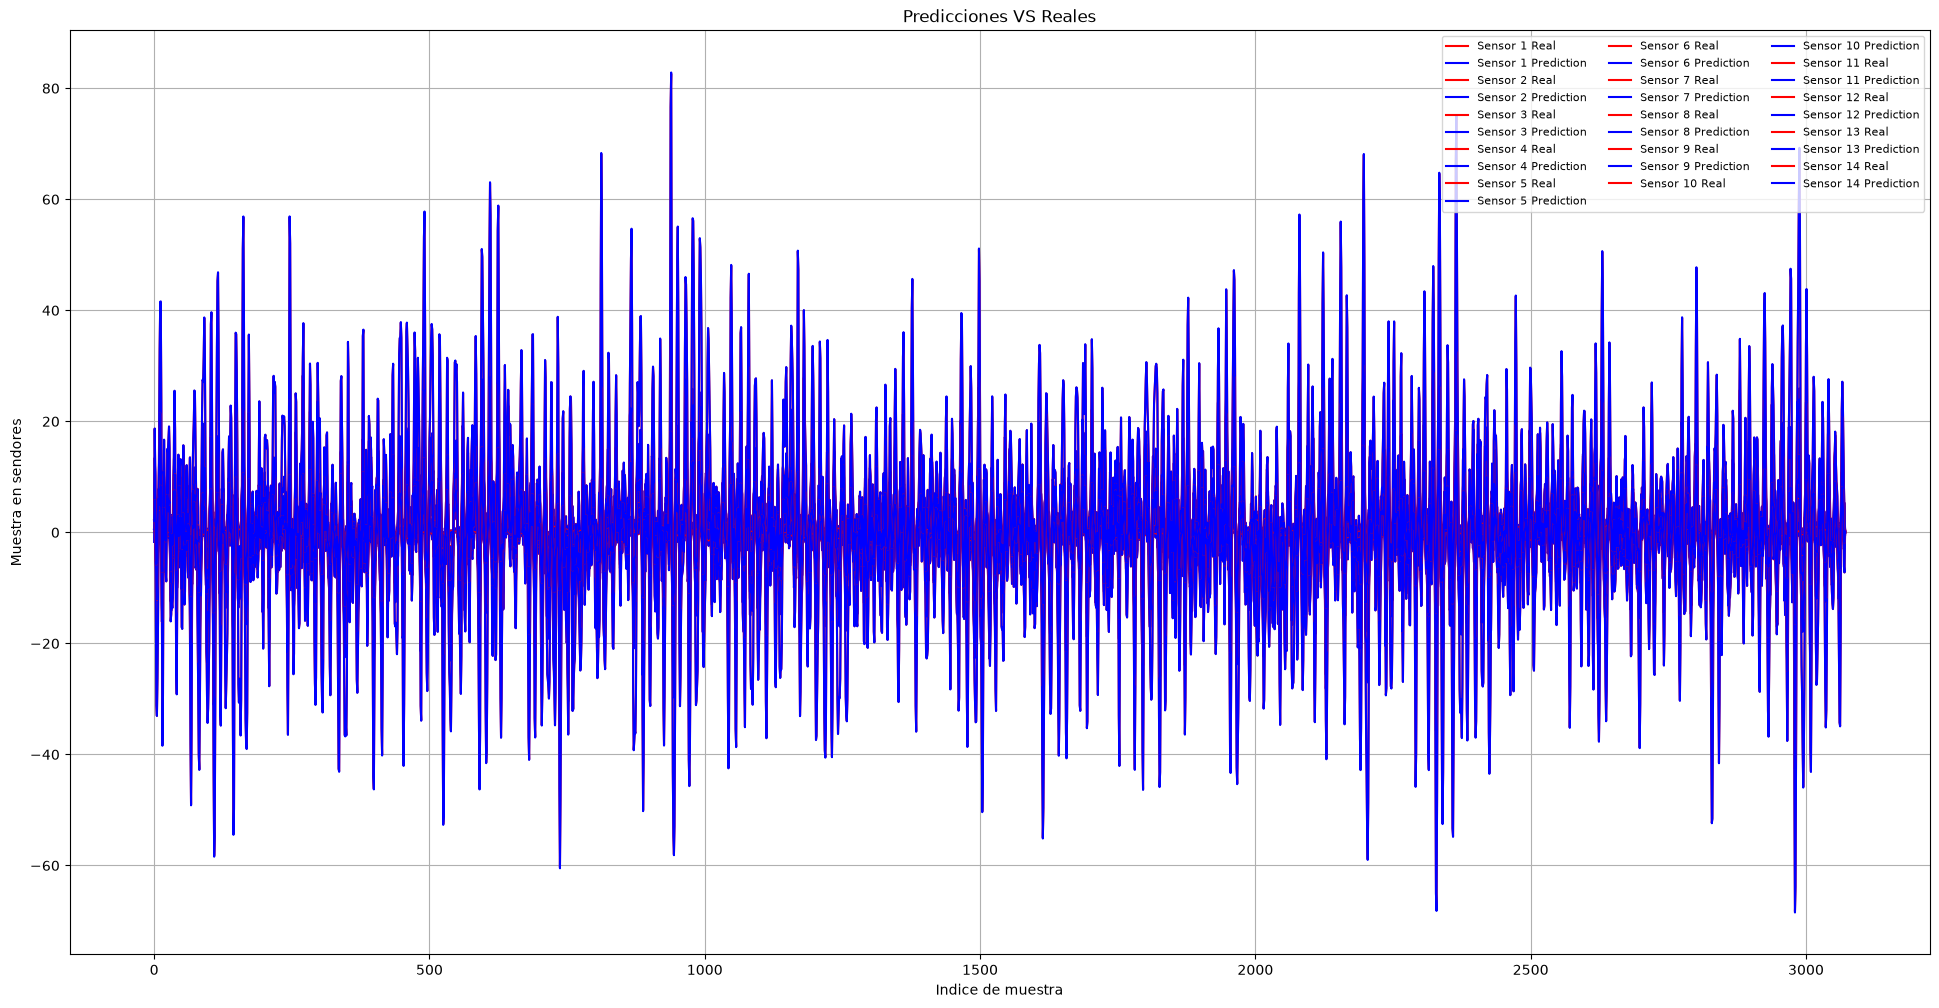

In [14]:
plt.figure(figsize = (24, 12))

for i in range(len(data[0])):
    # Datos reales
    plt.plot(range(len(data)), data[:, i], "r", label = f"Sensor {i + 1} Real")
    # Predicciones
    plt.plot(range(len(xf)), xf[:, i], "b", label = f"Sensor {i + 1} Prediction")

plt.xlabel("Indice de muestra")
plt.ylabel("Muestra en sendores")
plt.title("Predicciones VS Reales")
plt.legend(loc = "upper right", ncol = 3, fontsize = 8)
plt.grid(True)
plt.show()